# Working with Real Image Data
Project includes working with the real data from a varied collection of .jpg files.
In this section, we will work with a curated version of the Cats vs. Dogs dataset, originally inspired by the classic <a href='https://www.kaggle.com/c/dogs-vs-cats'>Kaggle competition</a>
. Unlike the raw Kaggle dataset, our version has been cleaned to remove corrupt files (such as 0x0 images) and ensure consistency. The images are similar to those available in the <a href='http://www.image-net.org/'>ImageNet</a>
 database.

To facilitate training and evaluation, the dataset has been structured into train and test directories, with further subdivisions into CAT and DOG folders. This directory structure allows the file paths themselves to encode the image labels, simplifying the data loading process.

In [574]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from torchvision.utils import make_grid

In [575]:
import os
from PIL import Image
from IPython.display import display

import warnings
warnings.filterwarnings('ignore') ## To ignore new version or any unimportant warnings

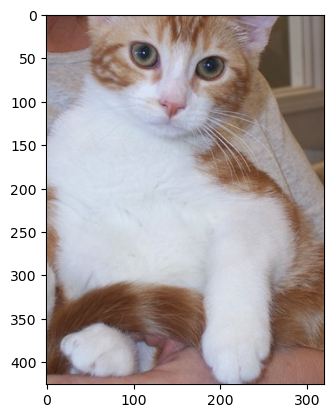

In [576]:
with Image.open('/Users/mohammadanas/Downloads/PyTorch for Deep Learning/CATS_DOGS/train/CAT/9.jpg') as im:
    plt.imshow(im)

In [577]:
path = '/Users/mohammadanas/Downloads/PyTorch for Deep Learning/CATS_DOGS/'
img_names = []
for folder,subfolder,filenames in os.walk(path):
    for img in filenames:
        img_names.append(folder + '/' + img)

In [578]:
len(img_names)

24996

In [579]:
img_sizes = []
rejected = []
for item in img_names:
    try:
        with Image.open(item) as img:
            img_sizes.append(img.size)
    except:
        rejected.append(item)

In [580]:
len(rejected)

2

In [581]:
rejected

['/Users/mohammadanas/Downloads/PyTorch for Deep Learning/CATS_DOGS//.DS_Store',
 '/Users/mohammadanas/Downloads/PyTorch for Deep Learning/CATS_DOGS/train/.DS_Store']

In [582]:
for i in rejected:
    img_names.remove(i)

In [583]:
len(img_sizes)

24994

In [584]:
df = pd.DataFrame(img_sizes, columns=['width','length'])

In [585]:
df.head()

,width,length
0,365,500
1,484,500
2,448,500
3,500,483
4,500,375


In [586]:
df['width'].describe()

count    24994.000000
mean       404.493518
std        108.941802
min         42.000000
25%        323.000000
50%        448.000000
75%        500.000000
max        500.000000
Name: width, dtype: float64

In [587]:
df['length'].describe()

count    24994.000000
mean       361.037129
std         96.936811
min         33.000000
25%        302.000000
50%        375.000000
75%        421.000000
max        500.000000
Name: length, dtype: float64

Now, let's transform the images so that our dataset size can be increased as we only have around 25000 images. Let's flip the images with vertical axis.

In [588]:
dog = Image.open('/Users/mohammadanas/Downloads/PyTorch for Deep Learning/CATS_DOGS/train/DOG/20.jpg')
type(dog)

PIL.JpegImagePlugin.JpegImageFile

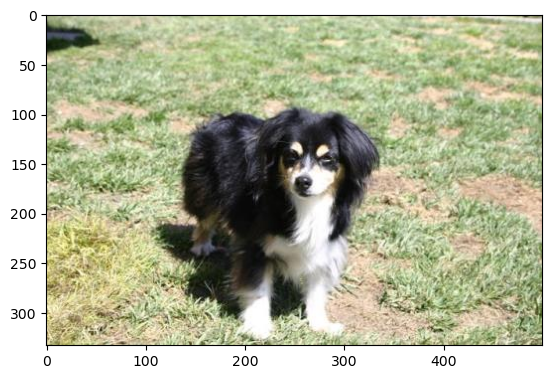

In [589]:
plt.imshow(dog)

In [590]:
dog.size

(500, 333)

In [591]:
transform = transforms.Compose([
    transforms.ToTensor()
])
im2 = transform(dog)
print(type(im2))
print(im2.shape)

<class 'torch.Tensor'>
torch.Size([3, 333, 500])


If we plot using plt.imshow(im2) it will give an error because it is not in correct format.

Observation, the size of the image is opposite to that of a tensor.
[Color,Height,Width]
Meaning on converting the image to tensor, the tensor size will be opposite to image size. But, in order to plot the image using an array rather than PIL we have to change the shape so that it will become compatible with the format of "plt.imshow" which is [Height,Width,Color] for that we can use np.transpose function.

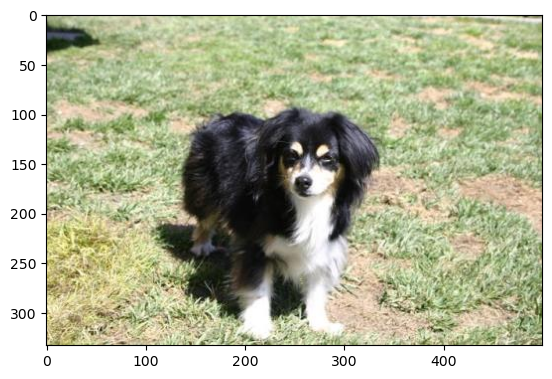

In [592]:
dog_tensor = np.transpose(im2.numpy(), (1, 2, 0))
plt.imshow(dog_tensor)  # convert [C,H,W] -> [H,W,C]

In [593]:
type(dog_tensor)

numpy.ndarray

Here we can see that our image is now converted into array. Which can be used for making more images from our datasets. This can be done by either resizing the image, flipping the image etc.

In [594]:
dog.getpixel((0,0))

(124, 135, 93)

In [595]:
dog_tensor[0,0,:]

array([0.4862745, 0.5294118, 0.3647059], dtype=float32)

Here, we can observe that the data tensor is a normalized tensor. It is better for training purposes.

## Image Transformations

**Let's resize an image to any random size of (200,500)**

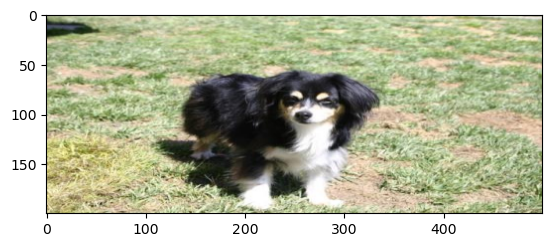

In [596]:
transform = transforms.Compose([
    transforms.Resize((200,500)),
    transforms.ToTensor()
])
im = transform(dog)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

**Let's crop an image** 

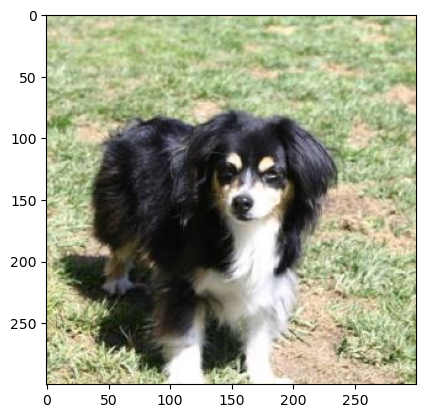

In [597]:
transform = transforms.Compose([
    transforms.CenterCrop((300,300)),
    transforms.ToTensor()
])
im = transform(dog)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

**Let's flip the image horizontally with probability of 1.**

Meaning the chances that the image be flipped is 100%. If p = 0.4, then on running the code again and again for 10 times, 4 times the flipped image will be there. 

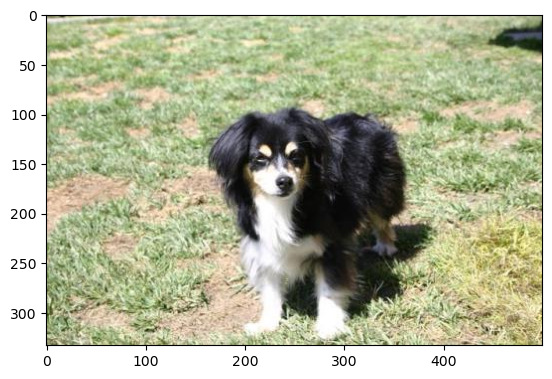

In [598]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 1),
    transforms.ToTensor()
])
im = transform(dog)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

**Let's rotate an image clockwise 30 degrees.**

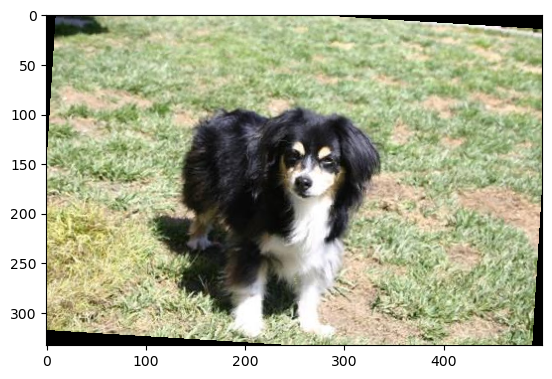

In [599]:
transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])
im = transform(dog)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

**Let's combine all the transformations**


torch.Size([3, 224, 224])


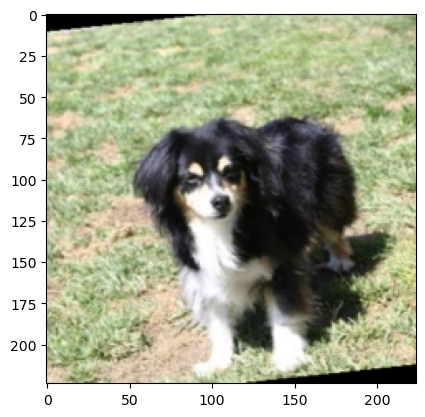

In [600]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),  # normally we'd set p=0.5
    transforms.RandomRotation(30),
    transforms.Resize(224),
    transforms.CenterCrop(224), 
    transforms.ToTensor()
])
im = transform(dog)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

___
## Normalization
Once the image has been loaded into a tensor, we can perform normalization on it. This serves to make convergence happen quicker during training. The values are somewhat arbitrary - you can use a mean of 0.5 and a standard deviation of 0.5 to convert a range of [0,1] to [-1,1], for example.<br>However, <a href='https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457/22'>research has shown</a> that mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225] work well in practice.

### <a href='https://pytorch.org/docs/stable/torchvision/transforms.html#torchvision.transforms.Normalize'><tt>transforms.Normalize(<em>mean, std</em>)</tt></a>
Given mean: (M1,...,Mn) and std: (S1,..,Sn) for n channels, this transform will normalize each channel of the input tensor
### $\quad\textrm {input[channel]} = \frac{\textrm{input[channel] - mean[channel]}}{\textrm {std[channel]}}$

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 333, 500])


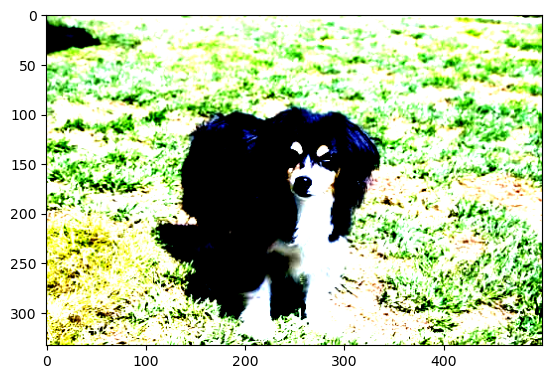

In [601]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
im = transform(dog)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

## Let's prepare our CNN model

In [602]:
train_transform = transforms.Compose([
        transforms.RandomRotation(10),      # rotate +/- 10 degrees
        transforms.RandomHorizontalFlip(),  # reverse 50% of images (default)
        transforms.Resize(224),             # resize shortest side to 224 pixels
        transforms.CenterCrop(224),         # crop longest side to 224 pixels at center
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

## Since we will evaluate our model performance using the test dataset, we don't need to rotate or flip images.
test_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

In [603]:
root = '/Users/mohammadanas/Downloads/PyTorch for Deep Learning/CATS_DOGS/'
train_data = datasets.ImageFolder(os.path.join(root,'train'),transform = train_transform)
test_data = datasets.ImageFolder(os.path.join(root,'test'),transform = test_transform)

torch.manual_seed(42)

train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle = False)

class_names = train_data.classes

In [604]:
class_names

['CAT', 'DOG']

In [605]:
len(train_data),len(test_data)

(18743, 6251)

In [606]:
# Grab the first batch of 10 images
for images,labels in train_loader: 
    break

# Print the labels
print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))

Label: [1 1 0 0 1 1 0 1 0 0]
Class: DOG DOG CAT CAT DOG DOG CAT DOG CAT CAT


In [607]:
images.shape 
# 10 -> Batch_size, 3 -> No of Color channels

torch.Size([10, 3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


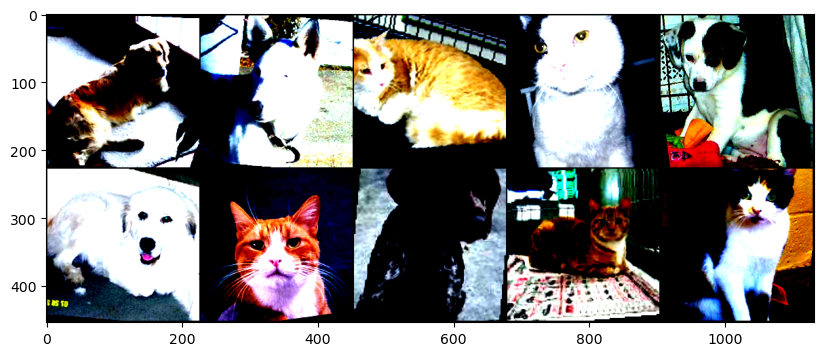

In [608]:
im = make_grid(images, nrow=5)  # the default nrow is 8
# Print the images
plt.figure(figsize=(12,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

This is because the images are already transformed, so in order to see the real images we have to inverse the tranformation and normalization.

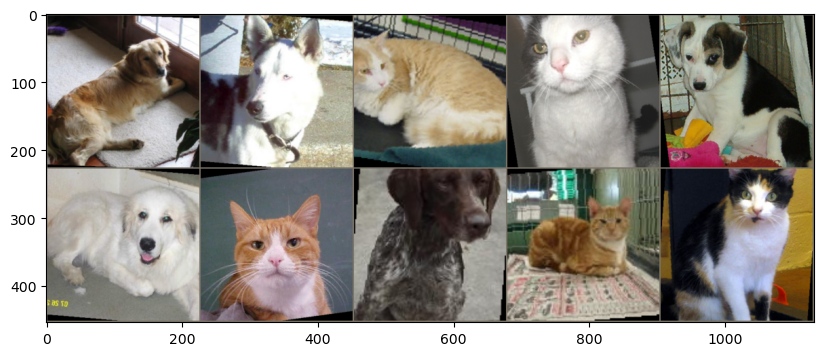

In [609]:
# Inverse normalize the images
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
im_inv = inv_normalize(im)

# Print the images
plt.figure(figsize=(12,4))
plt.imshow(np.transpose(im_inv.numpy(), (1, 2, 0)));

In [610]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        self.fc1 = nn.Linear(54*54*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 54*54*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

In [611]:
torch.manual_seed(101)
CNNmodel = ConvolutionalNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNNmodel.parameters(), lr=0.001)
CNNmodel

ConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=46656, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

In [612]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>8}')
    print(f'________\n{sum(params):>8}')

count_parameters(CNNmodel)

     162
       6
     864
      16
 5598720
     120
   10080
      84
     168
       2
________
 5610222


## Train the model
In the interests of time, we'll limit the number of training batches to 900, and the number of testing batches to 300, just to epochs faster. We'll train the model on 9000 of 18743 available images, and test it on 3000 out of 6251 images. 

In [613]:
import time
start_time = time.time()

epochs = 3

max_trn_batch = 900
max_tst_batch = 300

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        
        # Limit the number of batches
        if b == max_trn_batch:
            break
        b+=1
        
        # Apply the model
        y_pred = CNNmodel(X_train)
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print interim results
        if b%300 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/9000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            # Limit the number of batches
            if b == max_tst_batch:
                break

            # Apply the model
            y_val = CNNmodel(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:  0  batch:  300 [  3000/9000]  loss: 0.62094629  accuracy:  56.200%
epoch:  0  batch:  600 [  6000/9000]  loss: 0.63306785  accuracy:  60.317%
epoch:  0  batch:  900 [  9000/9000]  loss: 0.60903019  accuracy:  62.767%
epoch:  1  batch:  300 [  3000/9000]  loss: 0.61881882  accuracy:  69.833%
epoch:  1  batch:  600 [  6000/9000]  loss: 0.63177431  accuracy:  70.167%
epoch:  1  batch:  900 [  9000/9000]  loss: 0.55130184  accuracy:  71.922%
epoch:  2  batch:  300 [  3000/9000]  loss: 0.47305912  accuracy:  76.400%
epoch:  2  batch:  600 [  6000/9000]  loss: 0.71955305  accuracy:  75.433%
epoch:  2  batch:  900 [  9000/9000]  loss: 0.42671990  accuracy:  75.489%

Duration: 265 seconds


## Save the trained model

In [614]:
torch.save(CNNmodel.state_dict(), 'CustomImageCNNModel.pt')

## Evaluate the performance of the model

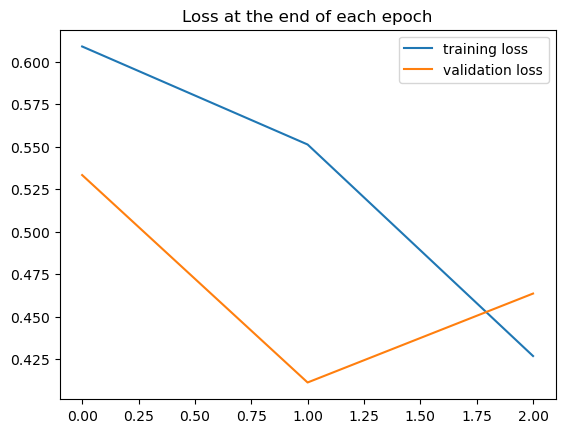

In [615]:
plt.plot([train_losses[i].detach().numpy() for i in range(len(train_losses))], label='training loss')
plt.plot([test_losses[i].detach().numpy() for i in range(len(test_losses))], label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();

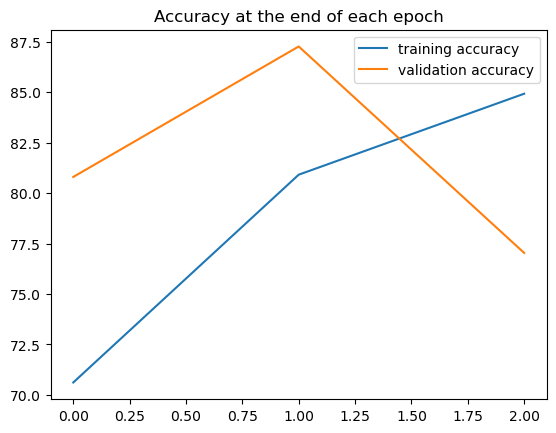

In [616]:
plt.plot([t/80 for t in train_correct], label='training accuracy')
plt.plot([t/30 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();

In [617]:
print(test_correct)
print(f'Test accuracy: {test_correct[-1].item()*100/3000:.3f}%')

[tensor(2424), tensor(2618), tensor(2311)]
Test accuracy: 77.033%


## Working with Pretrained model

In [618]:
AlexNetmodel = models.alexnet(pretrained=True)

## Freeze feature parameters
We want to freeze the pre-trained weights & biases. We set <tt>.requires_grad</tt> to False so we don't backprop through them.

In [619]:
for param in AlexNetmodel.parameters():
    param.requires_grad = False

In [620]:
AlexNetmodel

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

But, here we can see that the number of output features are around 1000. So, in order to get the output as per our dataset, i.e. 2 output features, we have to modify the ANN part of it.

In [621]:
torch.manual_seed(42)
AlexNetmodel.classifier = nn.Sequential(
    nn.Linear(in_features=9216, out_features=1024), # 9216 / 9 = 1024
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(in_features=1024, out_features=2),
    nn.LogSoftmax(dim=1)
  )

In [622]:
AlexNetmodel

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, 

In [623]:
count_parameters(AlexNetmodel)

 9437184
    1024
    2048
       2
________
 9440258


In [624]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(AlexNetmodel.classifier.parameters(), lr=0.001)

## Train the model

**As, we are already using pre-trained model therefore, the weights and biases of CNN part will be fixed and model will be trained for only fully connected layers.**

In [625]:
import time
start_time = time.time()

epochs = 1

max_trn_batch = 900
max_tst_batch = 300

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        if b == max_trn_batch:
            break
        b+=1
        
        # Apply the model
        y_pred = AlexNetmodel(X_train)
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print interim results
        if b%300 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/9000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break

            # Apply the model
            y_val = AlexNetmodel(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:  0  batch:  300 [  3000/9000]  loss: 0.00204117  accuracy:  90.133%
epoch:  0  batch:  600 [  6000/9000]  loss: 0.29339275  accuracy:  91.700%
epoch:  0  batch:  900 [  9000/9000]  loss: 0.04388567  accuracy:  92.700%

Duration: 154 seconds


In [626]:
print(test_correct[-1].item())
print(f'Test accuracy: {test_correct[-1].item()*100/3000:.3f}%')

2758
Test accuracy: 91.933%


## Run a new image through the model
We can also pass a single image through the model to obtain a prediction.<br>
Pick a number from 0 to 6250, assign it to "x", and we'll use that value to select an image from the Cats and Dogs test set.

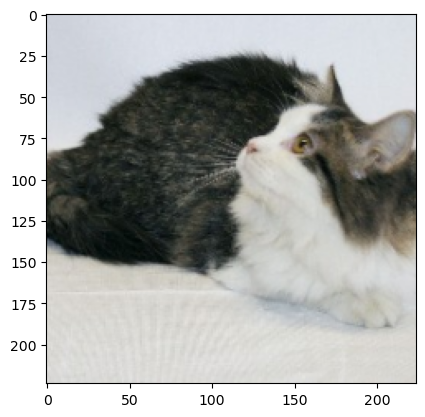

In [627]:
x = 2019
im = inv_normalize(test_data[x][0])
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

In [628]:
test_data[x][0].shape

torch.Size([3, 224, 224])

In [634]:
# CNN Model Prediction:

CNNmodel.eval()
with torch.no_grad():
    new_pred = CNNmodel(test_data[x][0].view(1,3,224,224)).argmax() 
    # This can also be written as new_pred = CNNmodel(test_data[x][0]).argmax() since we are only dealing with single image.
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 0 CAT


In [635]:
# AlexNet Model Prediction:

AlexNetmodel.eval()
with torch.no_grad():
    new_pred = AlexNetmodel(test_data[x][0].view(1,3,224,224)).argmax()
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 0 CAT


In [636]:
CNNmodel(test_data[x][0]).argmax()

tensor(0)

## Thanks